# Классификация SI > 8

Это уже более практичный и более дисбалансный сценарий, поэтому главным ориентиром становится `PR-AUC`.

Порог `8` захардкожен намеренно: он стабилен для этой постановки и фигурирует в критериях оценки.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Рабочая директория: {PROJECT_ROOT}')

Рабочая директория: /Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry


In [2]:
from types import SimpleNamespace

import pandas as pd
from IPython.display import Image, display

from src.common.config import RESULTS_DIR, TASKS
from src.common.data import find_dataset_path, load_dataset
from src.common.preprocessing import prepare_task_data
from src.common.training import run_regression_si_task, run_supervised_task

## Настройки запуска

По умолчанию стоит полный режим `nested`. Если нужен быстрый прогон для проверки,
достаточно переключить `EVALUATION_STRATEGY` на `"holdout"`.

In [3]:
TASK_NAME = 'classification_si_gt_8'
EVALUATION_STRATEGY = 'nested'
MODELS = None
SKIP_CATBOOST = False
OUTER_FOLDS = 5
INNER_FOLDS = 3
TEST_SIZE = 0.2
RANDOM_SEED = 42
TOP_K_IMPORTANCE = 20

task = TASKS[TASK_NAME]
dataframe = load_dataset(find_dataset_path())
prepared = prepare_task_data(dataframe, task)

print(f'Задача: {task.title}')
print(f'Матрица признаков: {prepared["X"].shape}')
print(f'Число признаков после фильтрации: {len(prepared["feature_columns"])}')
print(f'Статус проверки на утечку: {prepared["leakage_report"]["status"]}')

Задача: Классификация: SI > 8
Матрица признаков: (1001, 210)
Число признаков после фильтрации: 210
Статус проверки на утечку: passed


## Быстрый срез по таргету

Перед обучением полезно один раз посмотреть, что именно мы подаём в модель.

In [12]:
target_frame = (
    prepared['y']
    .value_counts()
    .sort_index()
    .rename_axis('label')
    .reset_index(name='count')
)
target_frame['share'] = target_frame['count'] / target_frame['count'].sum()
display(target_frame)

,label,count,share
0,0,644,0.643357
1,1,357,0.356643


## Запуск эксперимента

Эта ячейка пересчитывает результаты, пишет артефакты в `results/` и обновляет текстовый отчёт в `reports/`.

In [5]:
args = SimpleNamespace(
    evaluation_strategy=EVALUATION_STRATEGY,
    models=MODELS,
    skip_catboost=SKIP_CATBOOST,
    outer_folds=OUTER_FOLDS,
    inner_folds=INNER_FOLDS,
    test_size=TEST_SIZE,
    random_seed=RANDOM_SEED,
    top_k_importance=TOP_K_IMPORTANCE,
)

summary = run_supervised_task(task, args)
summary

2026-04-20 17:53:02,257 | INFO | Running classification_si_gt_8 with models: ['dummy', 'logistic_regression', 'knn', 'svc', 'random_forest', 'extra_trees', 'gradient_boosting', 'catboost']
2026-04-20 17:53:02,257 | INFO | Evaluating model dummy
2026-04-20 17:53:02,934 | INFO | Evaluating model logistic_regression
2026-04-20 17:53:10,248 | INFO | Evaluating model knn
2026-04-20 17:53:22,095 | INFO | Evaluating model svc
2026-04-20 17:53:52,659 | INFO | Evaluating model random_forest
2026-04-20 18:01:36,796 | INFO | Evaluating model extra_trees
2026-04-20 18:04:53,278 | INFO | Evaluating model gradient_boosting
2026-04-20 18:08:59,381 | INFO | Evaluating model catboost
2026-04-20 18:23:47,993 | INFO | Finished classification_si_gt_8. Winner: extra_trees


{'task_name': 'classification_si_gt_8',
 'title': 'Классификация: SI > 8',
 'problem_type': 'classification',
 'target_column': 'SI',
 'threshold': 8.0,
 'primary_metric': 'pr_auc',
 'evaluation_strategy': 'nested',
 'random_seed': 42,
 'data_contract_path': '/Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/results/data_contract.json',
 'leaderboard_path': '/Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/results/classification_si_gt_8/leaderboard.csv',
 'winner': {'task_name': 'classification_si_gt_8',
  'problem_type': 'classification',
  'target_column': 'SI',
  'primary_metric': 'pr_auc',
  'evaluation_strategy': 'nested',
  'model_name': 'extra_trees',
  'mode': 'direct',
  'fit_seconds': 196.478914916981,
  'best_params_json': '{"class_weight": "balanced", "max_depth": 8, "max_features": 0.5, "min_samples_leaf": 5}',
  'roc_auc': 0.7385471779048537,
  'roc_auc_std': 0.026316950342803437,
  'f1': 0.5633431435167211,
  '

## Лидерборд

Сравнение разных моделей.

In [6]:
leaderboard = pd.read_csv(RESULTS_DIR / 'classification_si_gt_8' / 'leaderboard.csv')
display(leaderboard)

,task_name,problem_type,target_column,primary_metric,evaluation_strategy,model_name,mode,fit_seconds,best_params_json,roc_auc,roc_auc_std,f1,f1_std,balanced_accuracy,balanced_accuracy_std,pr_auc,pr_auc_std
0,classification_si_gt_8,classification,SI,pr_auc,nested,extra_trees,direct,196.478915,"{""class_weight"": ""balanced"", ""max_depth"": 8, ""...",0.738547,0.026317,0.563343,0.033520,0.666430,0.025038,0.676551,0.029607
1,classification_si_gt_8,classification,SI,pr_auc,nested,random_forest,direct,464.200050,"{""class_weight"": ""balanced"", ""max_depth"": 16, ...",0.730515,0.029831,0.555386,0.041635,0.662729,0.029058,0.667899,0.025806
2,classification_si_gt_8,classification,SI,pr_auc,nested,catboost,direct,888.544060,"{""depth"": 6, ""iterations"": 200, ""l2_leaf_reg"":...",0.728466,0.030416,0.525434,0.035233,0.648928,0.027730,0.643743,0.031701
3,classification_si_gt_8,classification,SI,pr_auc,nested,svc,direct,30.560229,"{""C"": 1.0, ""class_weight"": null, ""gamma"": ""auto""}",0.717293,0.009345,0.421583,0.212136,0.625818,0.064457,0.632624,0.016057
4,classification_si_gt_8,classification,SI,pr_auc,nested,gradient_boosting,direct,246.098858,"{""learning_rate"": 0.03, ""max_depth"": 3, ""n_est...",0.729024,0.017168,0.534914,0.028094,0.656944,0.014525,0.629097,0.031056
5,classification_si_gt_8,classification,SI,pr_auc,nested,knn,direct,11.844085,"{""n_neighbors"": 21, ""p"": 1, ""weights"": ""distan...",0.713823,0.025698,0.552475,0.034452,0.658650,0.026122,0.605654,0.059847
6,classification_si_gt_8,classification,SI,pr_auc,nested,logistic_regression,direct,7.310082,"{""C"": 0.01, ""class_weight"": null}",0.682388,0.016890,0.541873,0.018046,0.648583,0.016592,0.582722,0.015958
7,classification_si_gt_8,classification,SI,pr_auc,nested,dummy,direct,0.674730,"{""strategy"": ""stratified""}",0.498286,0.003428,0.056296,0.112593,0.491877,0.016246,0.355883,0.003027


## Короткий разбор результата

In [7]:
winner = leaderboard.iloc[0]
baseline_rows = leaderboard[leaderboard['model_name'] == 'dummy']
baseline = baseline_rows.iloc[0] if not baseline_rows.empty else None

print(
    f"Победитель: {winner['model_name']} "
    f"({winner['mode']}), "
    f"основная метрика {winner['primary_metric']} = {winner[winner['primary_metric']]:.6f}."
)
if baseline is not None:
    print(
        f"Для сравнения dummy даёт {baseline[baseline['primary_metric']]:.6f} по той же метрике."
    )
print(f"Лучшие параметры: {winner['best_params_json']}")

Победитель: extra_trees (direct), основная метрика pr_auc = 0.676551.
Для сравнения dummy даёт 0.355883 по той же метрике.
Лучшие параметры: {"class_weight": "balanced", "max_depth": 8, "max_features": 0.5, "min_samples_leaf": 5}


## Что видно по важности признаков

In [10]:
importance_path = RESULTS_DIR / 'classification_si_gt_8' / 'winner_feature_importance.csv'
if importance_path.exists():
    display(pd.read_csv(importance_path).head(15))

,feature,importance,abs_importance
0,fr_Imine,0.039905,0.039905
1,FractionCSP3,0.027860,0.027860
2,SMR_VSA7,0.024927,0.024927
3,NumSaturatedCarbocycles,0.024608,0.024608
4,fr_allylic_oxid,0.020069,0.020069
5,fr_Al_OH_noTert,0.016212,0.016212
6,fr_NH2,0.015545,0.015545
7,RingCount,0.015408,0.015408
8,NHOHCount,0.014565,0.014565
9,NumAliphaticHeterocycles,0.013165,0.013165


## Матрица ошибок

Для бинарных задач полезно смотреть не только на метрики, но и на тип ошибок.

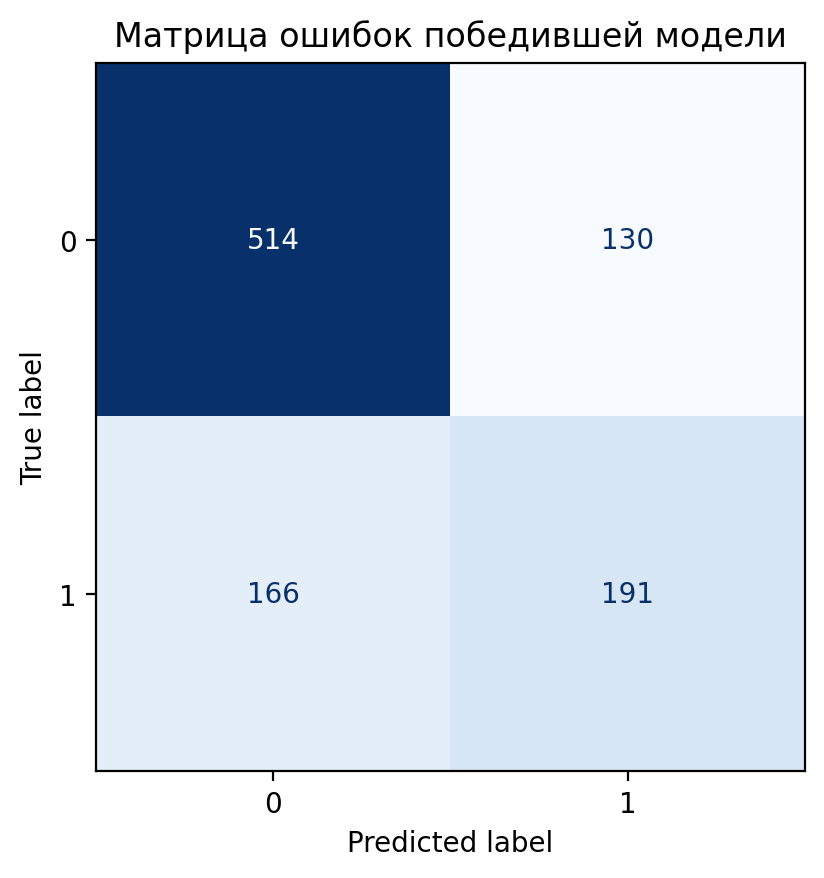

In [11]:
confusion_path = RESULTS_DIR / 'classification_si_gt_8' / 'winner_confusion_matrix.png'
if confusion_path.exists():
    display(Image(filename=str(confusion_path)))

## Итог
TODO: написать почему именно эта модель победила и порассуждать почему в этой задаче именно она показывает хороший результат